In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


In [ ]:
PT_PATH = Path("./results/spec_decode/cost_breakdown.pt")

DATASET = "alpaca"
TARGET_MODEL = "meta-llama/Llama-3.3-70B-Instruct"
DRAFT_MODEL_1B = "meta-llama/Llama-3.2-1B-Instruct"

BATCH_SIZES = [1, 4, 16, 64, 256]

METHOD_ORDER_THROUGHPUT = ["ar", "speculative", "magicdec", "eagle3"]
METHOD_ORDER_BREAKDOWN = ["speculative", "magicdec", "eagle3"]

METHOD_LABEL = {
    "ar": "Auto-regressive",
    "speculative": "Speculative Decoding",
    "magicdec": "MagicDec",
    "eagle3": "Eagle3",
}

SAVE_DIR = Path("./plots")
SAVE_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rc("font", size=12)

sns.set_palette("tab10")
sns.set_style("whitegrid")
palette = sns.color_palette("tab10")

AR_COLOR = palette[0]
SPEC_COLOR = palette[1]
MAGICDEC_COLOR = palette[2]
EAGLE3_COLOR = palette[3]

VERIFY_COLOR = palette[0]
DRAFT_COLOR = palette[1]
OTHERS_COLOR = palette[2]

METHOD_COLOR = {
    "ar": AR_COLOR,
    "speculative": SPEC_COLOR,
    "magicdec": MAGICDEC_COLOR,
    "eagle3": EAGLE3_COLOR,
}

FIGSIZE = (6, 2)

In [ ]:
# ============================================================
# Load cost_breakdown.pt into DataFrame
# ============================================================
obj = torch.load(PT_PATH, map_location="cpu", weights_only=False)
records = obj["records"]
df = pd.DataFrame(records)

print("Loaded records:", len(df))
print("Methods:", sorted(df["method"].dropna().unique().tolist()))
print("Datasets:", sorted(df["dataset"].dropna().unique().tolist()))
print("Batch sizes:", sorted(df["batch_size"].dropna().unique().tolist()))
print("Num spec tokens:", sorted(df["num_speculative_tokens"].dropna().unique().tolist()))

# %%
# ============================================================
# Basic filtering
# Keep the same filtering policy as the attached code:
#   1. AR baseline is not filtered by draft model
#   2. speculative / magicdec are filtered by draft_model=1B
#   3. eagle3 is kept as-is for the selected target model
# ============================================================
base_df = df[
    (df["dataset"] == DATASET) &
    (df["target_model"] == TARGET_MODEL) &
    (df["batch_size"].isin(BATCH_SIZES))
].copy()

base_df["throughput"] = base_df["total_output_tokens"] / base_df["wall_time_s"]
base_df["tpot"] = base_df["wall_time_s"] / base_df["total_output_tokens"]

ar_df = base_df[base_df["method"] == "ar"].copy()

spec_df = base_df[
    (base_df["method"] == "speculative") &
    (base_df["draft_model"] == DRAFT_MODEL_1B)
].copy()

magic_df = base_df[
    (base_df["method"] == "magicdec") &
    (base_df["draft_model"] == DRAFT_MODEL_1B)
].copy()

eagle_df = base_df[
    (base_df["method"] == "eagle3")
].copy()

throughput_df = pd.concat([ar_df, spec_df, magic_df, eagle_df], ignore_index=True)

# %%
# ============================================================
# Aggregate throughput
# ============================================================
throughput_agg = (
    throughput_df.groupby(["method", "batch_size"], as_index=False)
    .agg(
        throughput=("throughput", "mean"),
        num_samples=("throughput", "size"),
    )
)

print("Counts used for throughput bars")
print(throughput_agg.pivot(index="method", columns="batch_size", values="num_samples"))
print()

print("Mean throughput")
print(throughput_agg.pivot(index="method", columns="batch_size", values="throughput"))
print()


Loaded records: 38
Methods: ['ar', 'eagle3', 'magicdec', 'pivot', 'speculative', 'tetris']
Datasets: ['aime25', 'alpaca']
Batch sizes: [1, 4, 16, 64, 256]
Num spec tokens: [3]
Counts used for throughput bars
batch_size   1    4    16   64   256
method                              
ar           1.0  1.0  1.0  1.0  NaN
eagle3       1.0  1.0  1.0  NaN  NaN
magicdec     1.0  1.0  1.0  1.0  1.0
speculative  1.0  1.0  1.0  1.0  NaN

Mean throughput
batch_size          1           4           16           64           256
method                                                                   
ar            61.944644  151.470893  527.556942  1954.052583          NaN
eagle3       124.636238  292.258225  873.951697          NaN          NaN
magicdec     121.988997  270.427168  827.592727  2560.197336  4736.702657
speculative  122.078123  281.383395  849.748259  2563.145901          NaN



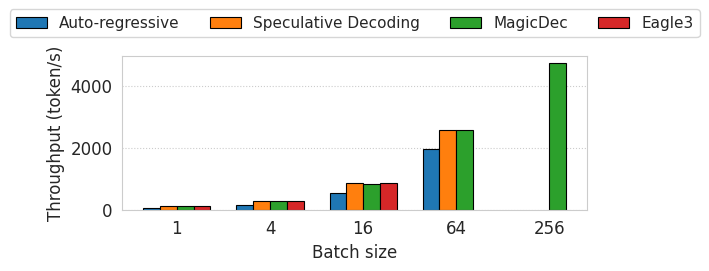

In [ ]:
# ============================================================
# Figure 1: Throughput vs batch size
# Same overall figure size as Figure 2
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)

x = np.arange(len(BATCH_SIZES))
bar_width = 0.18

offset_map = {
    "ar": -1.5 * bar_width,
    "speculative": -0.5 * bar_width,
    "magicdec": 0.5 * bar_width,
    "eagle3": 1.5 * bar_width,
}

for method in METHOD_ORDER_THROUGHPUT:
    sub = (
        throughput_agg[throughput_agg["method"] == method]
        .set_index("batch_size")
        .reindex(BATCH_SIZES)
    )
    y = sub["throughput"].to_numpy(dtype=float)
    ax.bar(
        x + offset_map[method],
        y,
        width=bar_width,
        color=METHOD_COLOR[method],
        edgecolor="black",
        linewidth=0.8,
        label=METHOD_LABEL[method],
    )

ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in BATCH_SIZES])
ax.set_xlabel("Batch size", fontsize=12)
ax.set_ylabel("Throughput (token/s)", fontsize=12)
ax.tick_params(axis="both", which="major", labelsize=12)

ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
ax.grid(False, axis="x")
ax.set_axisbelow(True)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.35),
    ncol=4,
    fancybox=True,
    shadow=False,
    fontsize=11,
    frameon=True,
)

# plt.subplots_adjust(top=0.82, bottom=0.16, left=0.12, right=0.98)
fig.savefig(SAVE_DIR / f"intro1_throughput_{DATASET}.pdf", dpi=600)
plt.show()

In [ ]:
# ============================================================
# Build AR baseline for normalized TPOT
# Normalize by AR TPOT of same dataset / target / batch size
# ============================================================
baseline_keys = ["dataset", "target_model", "batch_size"]

ar_baseline = (
    ar_df.groupby(baseline_keys, as_index=False)["tpot"]
    .mean()
    .rename(columns={"tpot": "ar_tpot"})
)

plot_df = pd.concat([spec_df, magic_df, eagle_df], ignore_index=True)
plot_df = plot_df.merge(ar_baseline, on=baseline_keys, how="inner")
plot_df["normalized_tpot"] = plot_df["tpot"] / plot_df["ar_tpot"]

# %%
# ============================================================
# TPOT breakdown
# others = wall_time_s - draft_time_s - verification_time_s
# ============================================================
plot_df["verification_time_s"] = plot_df["verification_time_s"].fillna(0.0)
plot_df["draft_time_s"] = plot_df["draft_time_s"].fillna(0.0)

plot_df["verify_ratio"] = plot_df["verification_time_s"] / plot_df["wall_time_s"]
plot_df["draft_ratio"] = plot_df["draft_time_s"] / plot_df["wall_time_s"]
plot_df["others_ratio"] = (
    (plot_df["wall_time_s"] - (plot_df["draft_time_s"] + plot_df["verification_time_s"]))
    / plot_df["wall_time_s"]
).clip(lower=0.0)

plot_df["verify_component"] = plot_df["normalized_tpot"] * plot_df["verify_ratio"]
plot_df["draft_component"] = plot_df["normalized_tpot"] * plot_df["draft_ratio"]
plot_df["others_component"] = plot_df["normalized_tpot"] * plot_df["others_ratio"]

agg = (
    plot_df.groupby(["method", "batch_size"], as_index=False)
    .agg(
        normalized_tpot=("normalized_tpot", "mean"),
        verify_component=("verify_component", "mean"),
        draft_component=("draft_component", "mean"),
        others_component=("others_component", "mean"),
        num_samples=("normalized_tpot", "size"),
    )
)

print("Counts used for each stacked bar")
print(agg.pivot(index="method", columns="batch_size", values="num_samples"))
print()

print("Mean normalized TPOT")
print(agg.pivot(index="method", columns="batch_size", values="normalized_tpot"))
print()

Counts used for each stacked bar
batch_size    1    4    16   64
method                         
eagle3       1.0  1.0  1.0  NaN
magicdec     1.0  1.0  1.0  1.0
speculative  1.0  1.0  1.0  1.0

Mean normalized TPOT
batch_size         1         4         16        64
method                                             
eagle3       0.497003  0.518278  0.603645       NaN
magicdec     0.507789  0.560117  0.637460  0.763243
speculative  0.507418  0.538308  0.620839  0.762365



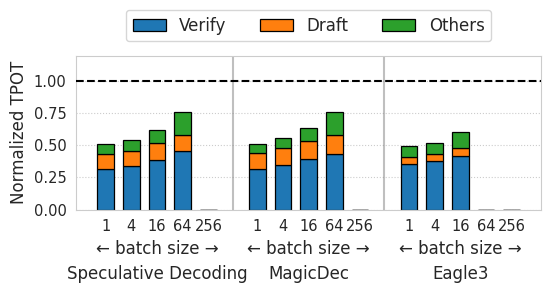

In [ ]:
# ============================================================
# Figure 2: Normalized TPOT breakdown
# Same layout logic as the attached code
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)

bar_width = 0.72
intra_gap = 1.1
group_gap = 2.10

x_map = {}
xticks = []
xticklabels = []
group_centers = []

cursor = 0.0
for method in METHOD_ORDER_BREAKDOWN:
    xs = cursor + np.arange(len(BATCH_SIZES)) * intra_gap
    x_map[method] = xs
    xticks.extend(xs)
    xticklabels.extend([str(b) for b in BATCH_SIZES])
    group_centers.append(xs.mean())
    cursor = xs[-1] + group_gap

for method in METHOD_ORDER_BREAKDOWN:
    sub = (
        agg[agg["method"] == method]
        .set_index("batch_size")
        .reindex(BATCH_SIZES)
    )

    xs = x_map[method]
    verify = sub["verify_component"].fillna(0).to_numpy()
    draft = sub["draft_component"].fillna(0).to_numpy()
    others = sub["others_component"].fillna(0).to_numpy()

    ax.bar(
        xs, verify, width=bar_width,
        color=VERIFY_COLOR, edgecolor="black", linewidth=0.9,
        label="Verify" if method == METHOD_ORDER_BREAKDOWN[0] else None,
    )
    ax.bar(
        xs, draft, width=bar_width, bottom=verify,
        color=DRAFT_COLOR, edgecolor="black", linewidth=0.9,
        label="Draft" if method == METHOD_ORDER_BREAKDOWN[0] else None,
    )
    ax.bar(
        xs, others, width=bar_width, bottom=verify + draft,
        color=OTHERS_COLOR, edgecolor="black", linewidth=0.9,
        label="Others" if method == METHOD_ORDER_BREAKDOWN[0] else None,
    )

for left_method, right_method in zip(METHOD_ORDER_BREAKDOWN[:-1], METHOD_ORDER_BREAKDOWN[1:]):
    x_sep = (x_map[left_method][-1] + x_map[right_method][0]) / 2.0
    ax.axvline(x=x_sep, color="grey", linestyle="-", alpha=0.5)

ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, zorder=10)

ax.set_ylabel("Normalized TPOT", fontsize=12)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.tick_params(axis="both", which="major", labelsize=10.5)

ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
ax.grid(False, axis="x")
ax.set_axisbelow(True)

trans = ax.get_xaxis_transform()
for center, method in zip(group_centers, METHOD_ORDER_BREAKDOWN):
    ax.text(center, -0.20, "← batch size →", ha="center", va="top", transform=trans)
    ax.text(center, -0.36, METHOD_LABEL[method], ha="center", va="top", transform=trans)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.35),
    ncol=3,
    fancybox=True,
    shadow=False,
    fontsize=12,
    frameon=True,
)

ymax = max(
    1.2,
    (agg["verify_component"] + agg["draft_component"] + agg["others_component"]).max() * 1.10
)
ax.set_ylim(0, ymax)

fig.savefig(SAVE_DIR / f"intro2_tpot_breakdown_{DATASET}.pdf", dpi=600)
plt.show()